
# Project Deliverable 3: Classification, Clustering, and Pattern Mining

**Student:** Sandeep Parupalli  
**Course:** 2026 Spring - Advanced Big Data and Data Mining (MSCS-634-B01)  
**Instructor:** Satish Penmatsa  
**Repository:** https://github.com/Sandeep271/Project-Deliverable-3-Classification-Clustering-and-Pattern-Mining

## Objective
This deliverable focuses on three tasks built on the cleaned Online Retail dataset:

1. Build and evaluate at least two classification models.
2. Tune one classification model to improve performance.
3. Develop a clustering solution and interpret the customer groups.
4. Apply association rule mining to identify meaningful product patterns.

The work below is limited to Deliverable 3 and is written to show the full code, intermediate outputs, and interpretation of results.



## 1. Import libraries and load the dataset

The analysis begins by importing the libraries needed for classification, clustering, visualization, and pattern mining.  
The Online Retail Excel file is then loaded from the working folder.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules

# Load the original dataset.
df = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")

print("Original dataset shape:", df.shape)
df.head()


Original dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



## 2. Prepare a cleaned transaction table

The same cleaning logic used earlier is applied here so the classification, clustering, and association rule results are based on valid records only.

### Cleaning choices
- Remove duplicate rows to avoid repeated transactions affecting the models.
- Drop rows with missing `Description` or `CustomerID` because they cannot be used reliably in customer-level modeling or market basket analysis.
- Remove rows where `Quantity <= 0` or `UnitPrice <= 0` because these usually represent returns, corrections, or invalid entries for this stage of analysis.
- Create `TotalSales` and `Month` as engineered features that are useful later in customer-level aggregation.


In [2]:

# Remove duplicated rows.
df_clean = df.drop_duplicates()

# Remove records with missing description or customer identifier.
df_clean = df_clean.dropna(subset=["Description", "CustomerID"])

# Keep only positive quantity and price records.
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()

# Create engineered features used in later sections.
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

print("Cleaned transaction dataset shape:", df_clean.shape)
df_clean.head()


Cleaned transaction dataset shape: (392692, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12



## 3. Create a customer-level modeling table

Deliverable 3 uses a customer-level view of the data because classification and clustering are easier to interpret when each row represents a customer rather than an individual invoice line.

### Customer-level features
- `NumTransactions`: number of unique invoices per customer
- `TotalQuantity`: total units purchased
- `AvgUnitPrice`: average unit price across purchases
- `TotalSpent`: total spending across all valid transactions
- `ActiveMonths`: number of distinct months with purchases


In [3]:

customer_df = df_clean.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "UnitPrice": "mean",
    "TotalSales": "sum",
    "Month": "nunique"
}).reset_index()

customer_df.columns = [
    "CustomerID",
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpent",
    "ActiveMonths"
]

print("Customer-level dataset shape:", customer_df.shape)
customer_df.head()


Customer-level dataset shape: (4338, 6)


,CustomerID,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths
0,12346.0,1,74215,1.040000,77183.60,1
1,12347.0,7,2458,2.644011,4310.00,6
2,12348.0,4,2341,5.764839,1797.24,4
3,12349.0,1,631,8.289041,1757.55,1
4,12350.0,1,197,3.841176,334.40,1



## 4. Build the classification target

A binary target called `HighValueCustomer` is created to separate customers into higher-spending and lower-spending groups.

### Target definition
- `1` = customer spent more than the median customer spend
- `0` = customer spent at or below the median customer spend

This approach creates balanced classes, which is useful for fair comparison of classification models.


In [4]:

customer_df["HighValueCustomer"] = (
    customer_df["TotalSpent"] > customer_df["TotalSpent"].median()
).astype(int)

print("Class distribution:")
print(customer_df["HighValueCustomer"].value_counts())


Class distribution:
HighValueCustomer
1    2169
0    2169
Name: count, dtype: int64



## 5. Split the classification data

The same four engineered predictors are used for both classification models.


In [5]:

X_cls = customer_df[["NumTransactions", "TotalQuantity", "AvgUnitPrice", "ActiveMonths"]]
y_cls = customer_df["HighValueCustomer"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

print("Training feature shape:", X_train_cls.shape)
print("Test feature shape:", X_test_cls.shape)


Training feature shape: (3470, 4)
Test feature shape: (868, 4)



## 6. Classification model 1 - Decision Tree

A Decision Tree is used as the first classification model because it is interpretable and handles non-linear relationships well.


In [6]:

# Train the baseline Decision Tree model.
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_cls, y_train_cls)

# Generate predictions.
y_pred_dt = dt_model.predict(X_test_cls)

# Store baseline metrics.
dt_accuracy = accuracy_score(y_test_cls, y_pred_dt)
dt_f1 = f1_score(y_test_cls, y_pred_dt)
dt_confusion = confusion_matrix(y_test_cls, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree F1 Score:", dt_f1)
print("Decision Tree Confusion Matrix:")
print(dt_confusion)


Decision Tree Accuracy: 0.9066820276497696
Decision Tree F1 Score: 0.9088863892013498
Decision Tree Confusion Matrix:
[[383  51]
 [ 30 404]]



## 7. Classification model 2 - k-NN

A k-NN model is used as the second classifier.  
Because k-NN is sensitive to feature scale, the predictors are standardized before fitting.


In [7]:

# Scale the features for k-NN.
scaler = StandardScaler()
X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

# Train the k-NN classifier.
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_cls_scaled, y_train_cls)

# Generate predictions.
y_pred_knn = knn_model.predict(X_test_cls_scaled)

# Store metrics.
knn_accuracy = accuracy_score(y_test_cls, y_pred_knn)
knn_f1 = f1_score(y_test_cls, y_pred_knn)
knn_confusion = confusion_matrix(y_test_cls, y_pred_knn)

print("k-NN Accuracy:", knn_accuracy)
print("k-NN F1 Score:", knn_f1)
print("k-NN Confusion Matrix:")
print(knn_confusion)


k-NN Accuracy: 0.9170506912442397
k-NN F1 Score: 0.9181818181818182
k-NN Confusion Matrix:
[[392  42]
 [ 30 404]]



## 8. Hyperparameter tuning for Decision Tree

Grid search is used to tune the Decision Tree model.

### Technique used
`GridSearchCV` systematically tests combinations of:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

### Why these parameters matter
- `max_depth` controls how complex the tree becomes.
- `min_samples_split` controls when a node is allowed to split.
- `min_samples_leaf` reduces overly specific leaf nodes and helps avoid overfitting.


In [8]:

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_search.fit(X_train_cls, y_train_cls)

best_dt_model = grid_search.best_estimator_
y_pred_best_dt = best_dt_model.predict(X_test_cls)

best_dt_accuracy = accuracy_score(y_test_cls, y_pred_best_dt)
best_dt_f1 = f1_score(y_test_cls, y_pred_best_dt)
best_dt_confusion = confusion_matrix(y_test_cls, y_pred_best_dt)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1:", grid_search.best_score_)
print("Tuned Decision Tree Accuracy:", best_dt_accuracy)
print("Tuned Decision Tree F1 Score:", best_dt_f1)
print("Tuned Decision Tree Confusion Matrix:")
print(best_dt_confusion)


Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1: 0.9272575121139548
Tuned Decision Tree Accuracy: 0.9182027649769585
Tuned Decision Tree F1 Score: 0.9204927211646137
Tuned Decision Tree Confusion Matrix:
[[386  48]
 [ 23 411]]



## 9. Compare classification results

The next table summarizes the three classification results:
- baseline Decision Tree
- k-NN
- tuned Decision Tree


In [9]:

classification_results = pd.DataFrame({
    "Model": ["Decision Tree", "k-NN", "Tuned Decision Tree"],
    "Accuracy": [dt_accuracy, knn_accuracy, best_dt_accuracy],
    "F1 Score": [dt_f1, knn_f1, best_dt_f1]
})

classification_results


,Model,Accuracy,F1 Score
0,Decision Tree,0.906682,0.908886
1,k-NN,0.917051,0.918182
2,Tuned Decision Tree,0.918203,0.920493



### Visual comparison of classification models
A grouped bar chart helps compare model performance more clearly.


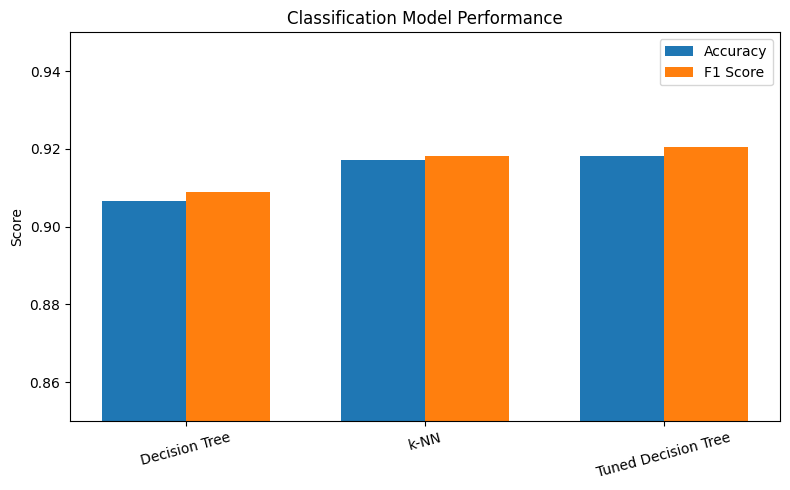

In [10]:

x = np.arange(len(classification_results))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, classification_results["Accuracy"], width, label="Accuracy")
plt.bar(x + width / 2, classification_results["F1 Score"], width, label="F1 Score")
plt.xticks(x, classification_results["Model"], rotation=15)
plt.ylim(0.85, 0.95)
plt.ylabel("Score")
plt.title("Classification Model Performance")
plt.legend()
plt.tight_layout()
plt.show()



## 10. Confusion matrix and ROC evaluation

The tuned Decision Tree is the best-performing classifier in this deliverable, so it is used for the final confusion matrix.  
A ROC comparison chart is also included to show how well the classifiers separate the two customer classes.


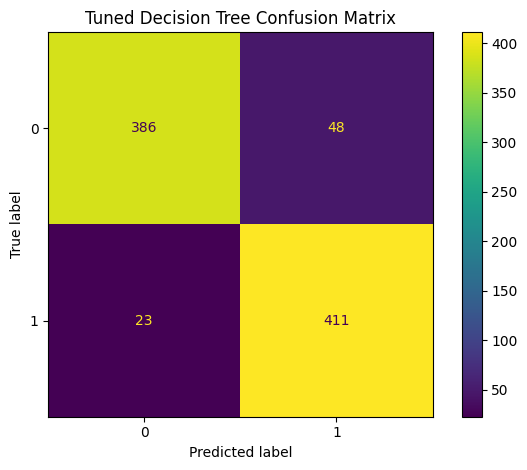

In [11]:

ConfusionMatrixDisplay.from_estimator(best_dt_model, X_test_cls, y_test_cls)
plt.title("Tuned Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


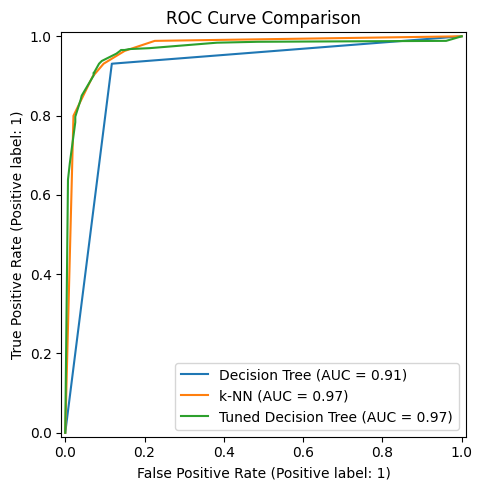

In [12]:

# Compare ROC curves for the three classification models.
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(dt_model, X_test_cls, y_test_cls, name="Decision Tree", ax=ax)
RocCurveDisplay.from_estimator(knn_model, X_test_cls_scaled, y_test_cls, name="k-NN", ax=ax)
RocCurveDisplay.from_estimator(best_dt_model, X_test_cls, y_test_cls, name="Tuned Decision Tree", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()



## 11. Clustering with K-Means

A K-Means clustering model is built using the same customer-level perspective.

### Features used for clustering
- `NumTransactions`
- `TotalQuantity`
- `AvgUnitPrice`
- `TotalSpent`
- `ActiveMonths`

These features are standardized so that large-value variables do not dominate the clustering process.


In [13]:

cluster_features = customer_df[[
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpent",
    "ActiveMonths"
]]

cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_counts = customer_df["Cluster"].value_counts().sort_index()
cluster_counts


Cluster
0    3705
1      17
2     616
Name: count, dtype: int64


### Cluster sizes
This chart shows how customers are distributed across the three clusters.


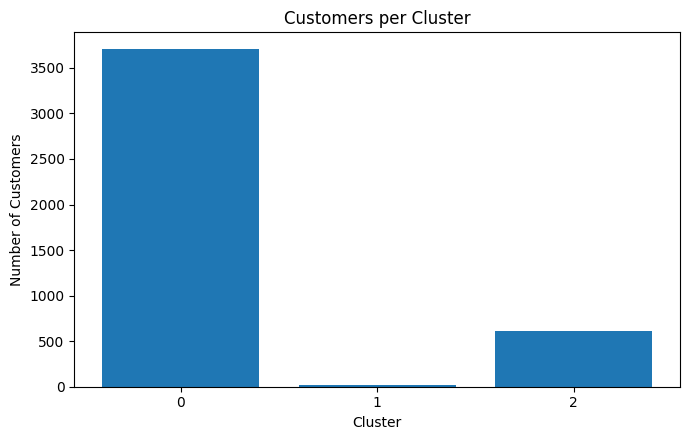

In [14]:

plt.figure(figsize=(7, 4.5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()



### Cluster profile summary
The table below helps interpret the clusters based on average customer behavior.


In [15]:

cluster_summary = customer_df.groupby("Cluster")[[
    "NumTransactions",
    "TotalQuantity",
    "AvgUnitPrice",
    "TotalSpent",
    "ActiveMonths"
]].mean().round(3)

cluster_summary


,NumTransactions,TotalQuantity,AvgUnitPrice,TotalSpent,ActiveMonths
Cluster,,,,,
0,2.454,520.013,4.639,874.653,2.096
1,70.353,64439.176,4.643,112579.268,10.353
2,13.385,3457.612,3.454,6059.695,7.917



### PCA view of the clusters
A two-dimensional PCA projection is used to visualize the customer groups.


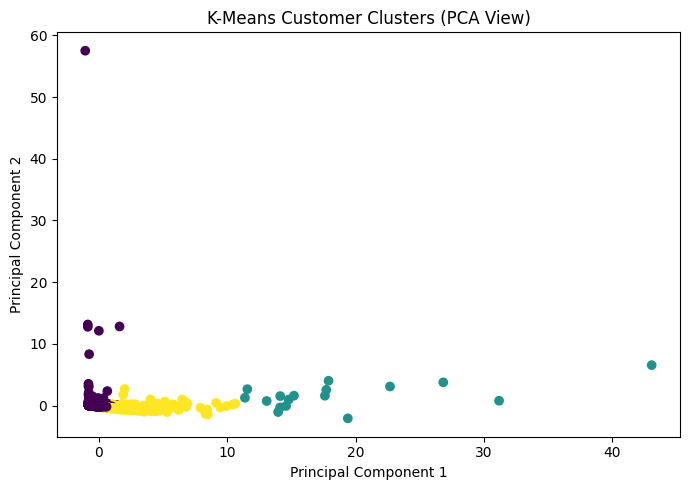

In [16]:

pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=customer_df["Cluster"])
plt.title("K-Means Customer Clusters (PCA View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()



### Interpretation of the cluster groups

Based on the cluster summary:
- **Cluster 0** contains lower-activity, lower-spending customers.
- **Cluster 2** contains mid-level customers with stronger engagement and higher total spend than Cluster 0.
- **Cluster 1** is a very small but extremely high-value segment with much larger transaction counts, quantities, and spending.

This segmentation could support targeted marketing, loyalty programs, and differentiated customer service strategies.



## 12. Association rule mining with Apriori

Association rule mining is used to discover product combinations that frequently appear together.

### Approach used
- Keep the top 20 most frequent products to keep the basket table manageable and interpretable.
- Build a basket matrix at the invoice level.
- Run Apriori with a minimum support threshold of 2%.
- Generate rules using lift so stronger-than-random relationships stand out.


In [17]:

top_products = df_clean["Description"].value_counts().head(20).index

basket_df = df_clean[df_clean["Description"].isin(top_products)]

basket = (
    basket_df.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

# Convert quantities into simple purchased / not-purchased flags.
basket = basket > 0

print("Basket shape:", basket.shape)
basket.head()


Basket shape: (10776, 20)


Description,ALARM CLOCK BAKELIKE RED,ASSORTED COLOUR BIRD ORNAMENT,HEART OF WICKER SMALL,JUMBO BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.,LUNCH BAG CARS BLUE,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN,NATURAL SLATE HEART CHALKBOARD,PACK OF 72 RETROSPOT CAKE CASES,PAPER CHAIN KIT 50'S CHRISTMAS,PARTY BUNTING,POSTAGE,REGENCY CAKESTAND 3 TIER,REX CASH+CARRY JUMBO SHOPPER,SET OF 3 CAKE TINS PANTRY DESIGN,SPOTTY BUNTING,WHITE HANGING HEART T-LIGHT HOLDER
InvoiceNo,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
536367,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
536370,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
536371,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
536373,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [18]:

frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
print("Frequent itemsets shape:", frequent_items.shape)
frequent_items.head(10)


Frequent itemsets shape: (69, 2)


,support,itemsets
0,0.081385,(ALARM CLOCK BAKELIKE RED )
1,0.127598,(ASSORTED COLOUR BIRD ORNAMENT)
2,0.089180,(HEART OF WICKER SMALL)
3,0.148478,(JUMBO BAG RED RETROSPOT)
4,0.097624,(LUNCH BAG BLACK SKULL.)
5,0.089644,(LUNCH BAG CARS BLUE)
6,0.086396,(LUNCH BAG PINK POLKADOT)
7,0.119525,(LUNCH BAG RED RETROSPOT)
8,0.091685,(LUNCH BAG SPACEBOY DESIGN )
9,0.083426,(LUNCH BAG SUKI DESIGN )


In [19]:

rules = association_rules(frequent_items, metric="lift", min_threshold=1.0)

top_rules = rules[["antecedents", "consequents", "support", "confidence", "lift"]].sort_values(
    by="lift",
    ascending=False
).copy()

# Convert frozensets to readable text for display.
top_rules["antecedents"] = top_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
top_rules["consequents"] = top_rules["consequents"].apply(lambda x: ", ".join(list(x)))

print("Rules shape:", rules.shape)
top_rules.head(10)


Rules shape: (160, 14)


,antecedents,consequents,support,confidence,lift
60,"LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE",LUNCH BAG PINK POLKADOT,0.024128,0.617577,7.148240
61,LUNCH BAG PINK POLKADOT,"LUNCH BAG BLACK SKULL., LUNCH BAG CARS BLUE",0.024128,0.279270,7.148240
122,LUNCH BAG PINK POLKADOT,"LUNCH BAG RED RETROSPOT, LUNCH BAG CARS BLUE",0.025891,0.299678,7.050934
119,"LUNCH BAG RED RETROSPOT, LUNCH BAG CARS BLUE",LUNCH BAG PINK POLKADOT,0.025891,0.609170,7.050934
83,"LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKULL.",LUNCH BAG PINK POLKADOT,0.028582,0.595745,6.895537
86,LUNCH BAG PINK POLKADOT,"LUNCH BAG RED RETROSPOT, LUNCH BAG BLACK SKULL.",0.028582,0.330827,6.895537
124,"LUNCH BAG SPACEBOY DESIGN , LUNCH BAG PINK POL...",LUNCH BAG CARS BLUE,0.020601,0.604905,6.747880
129,LUNCH BAG CARS BLUE,"LUNCH BAG SPACEBOY DESIGN , LUNCH BAG PINK POL...",0.020601,0.229814,6.747880
125,"LUNCH BAG SPACEBOY DESIGN , LUNCH BAG CARS BLUE",LUNCH BAG PINK POLKADOT,0.020601,0.567775,6.571797
128,LUNCH BAG PINK POLKADOT,"LUNCH BAG SPACEBOY DESIGN , LUNCH BAG CARS BLUE",0.020601,0.238453,6.571797



### Visualize the strongest association rules
The next chart compares the lift values of the strongest rules.


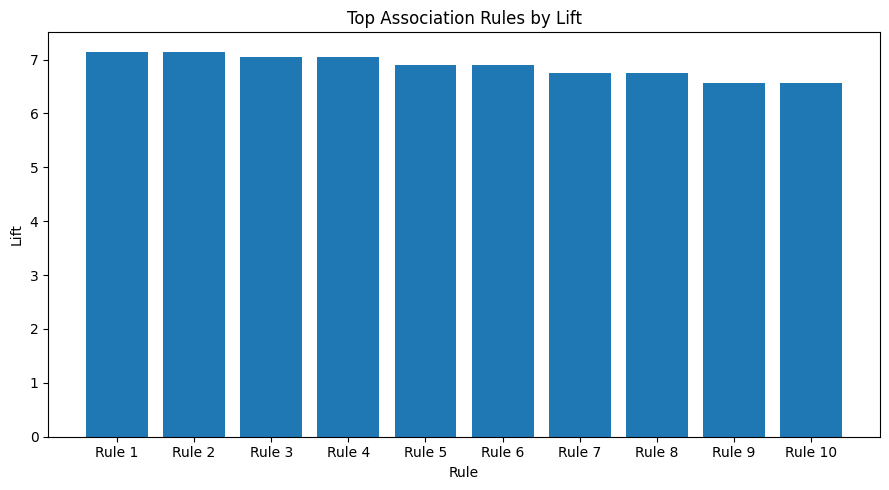

In [20]:

top_rules_plot = top_rules.head(10).reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.bar([f"Rule {i+1}" for i in range(len(top_rules_plot))], top_rules_plot["lift"])
plt.title("Top Association Rules by Lift")
plt.xlabel("Rule")
plt.ylabel("Lift")
plt.tight_layout()
plt.show()



### Real-world relevance of the discovered patterns

The strongest rules show that several themed lunch bag products are frequently purchased together.  
These patterns can be used in practice to support:

- product bundling
- recommendation systems
- cross-selling on e-commerce product pages
- targeted promotions during checkout

For example, if one lunch bag design is added to a cart, the retailer can recommend related lunch bag styles that often appear in the same basket.



## 13. Key insights and conclusion

### Classification
- The tuned Decision Tree performed best with the highest Accuracy and F1 Score.
- Hyperparameter tuning improved the baseline Decision Tree and slightly outperformed k-NN.
- The classification models show that simple engineered customer features can separate higher-value and lower-value customers effectively.

### Clustering
- K-Means identified three meaningful customer groups.
- One group contains a very small but extremely valuable segment that may deserve special retention attention.
- Another large group contains lower-spending customers who may benefit from re-engagement strategies.

### Pattern mining
- The association rules highlight clear co-purchase relationships among popular product designs.
- These findings have direct value for merchandising, promotions, and recommendation logic.

### Challenges and how they were addressed
- Missing values and duplicate records were removed before modeling.
- Returned or corrected transactions were filtered out by removing non-positive quantity and price rows.
- Feature scaling was applied before k-NN and clustering to avoid distortion from large numeric values.
- Grid search was used to tune the Decision Tree rather than relying on default settings.

Overall, the deliverable shows that customer behavior in the Online Retail dataset can be analyzed from several perspectives, and each method contributes useful business insight.
